In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
df=pd.read_csv('/content/midfielders_dataset (1).csv')
df

,player_name,age,nationality,club,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_history,matches_played,key_passes,dribbles,chances_created,pass_accuracy,transfer_risk_level
0,Rodri,27.0,Spain,Manchester City,91.0,92,164M,2.0,4,25,104,86,79,87.5,Low
1,Kevin De Bruyne,25.0,Belgium,Manchester City,75.0,92,43M,2.0,6,16,110,60,39,85.8,High
2,Jude Bellingham,20.0,England,Real Madrid,75.0,94,170M,1.0,5,32,92,45,91,77.3,High
3,Pedri,21.0,Spain,Barcelona,75.0,93,163M,2.0,4,20,110,23,26,94.7,High
4,Luka Modric,38.0,Croatia,Real Madrid,75.0,87,4M,1.0,4,24,85,58,33,76.9,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Park Smith,23.0,Ghana,Torino,75.0,83,2M,3.0,1,40,98,61,24,86.3,High
2996,Carlos Kato,19.0,Japan,Torino,75.0,80,6M,5.0,2,21,111,39,46,88.6,High
2997,Florian Romano,NaN,Poland,Lazio,87.0,97,63M,1.0,2,13,91,92,82,84.5,High
2998,Bruno Smith,25.0,Switzerland,Liverpool,69.0,69,9M,4.0,3,38,111,31,78,77.4,High


In [ ]:
df.shape

(3000, 15)

In [ ]:
df.head()

,player_name,age,nationality,club,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_history,matches_played,key_passes,dribbles,chances_created,pass_accuracy,transfer_risk_level
0,Rodri,27.0,Spain,Manchester City,91.0,92,164M,2.0,4,25,104,86,79,87.5,Low
1,Kevin De Bruyne,25.0,Belgium,Manchester City,75.0,92,43M,2.0,6,16,110,60,39,85.8,High
2,Jude Bellingham,20.0,England,Real Madrid,75.0,94,170M,1.0,5,32,92,45,91,77.3,High
3,Pedri,21.0,Spain,Barcelona,75.0,93,163M,2.0,4,20,110,23,26,94.7,High
4,Luka Modric,38.0,Croatia,Real Madrid,75.0,87,4M,1.0,4,24,85,58,33,76.9,High


In [ ]:
df.tail()

,player_name,age,nationality,club,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_history,matches_played,key_passes,dribbles,chances_created,pass_accuracy,transfer_risk_level
2995,Park Smith,23.0,Ghana,Torino,75.0,83,2M,3.0,1,40,98,61,24,86.3,High
2996,Carlos Kato,19.0,Japan,Torino,75.0,80,6M,5.0,2,21,111,39,46,88.6,High
2997,Florian Romano,NaN,Poland,Lazio,87.0,97,63M,1.0,2,13,91,92,82,84.5,High
2998,Bruno Smith,25.0,Switzerland,Liverpool,69.0,69,9M,4.0,3,38,111,31,78,77.4,High
2999,Ahmed Watanabe,26.0,Senegal,Al Hilal,74.0,75,23M,1.0,2,21,78,42,53,85.6,High


In [ ]:
df.dtypes

,0
player_name,object
age,float64
nationality,object
club,object
overall_rating,float64
potential_rating,int64
market_value_million_eur,object
contract_years_left,float64
injury_history,int64
matches_played,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_name               3000 non-null   object 
 1   age                       2955 non-null   float64
 2   nationality               3000 non-null   object 
 3   club                      3000 non-null   object 
 4   overall_rating            2960 non-null   float64
 5   potential_rating          3000 non-null   int64  
 6   market_value_million_eur  3000 non-null   object 
 7   contract_years_left       2950 non-null   float64
 8   injury_history            3000 non-null   int64  
 9   matches_played            3000 non-null   int64  
 10  key_passes                3000 non-null   int64  
 11  dribbles                  3000 non-null   int64  
 12  chances_created           3000 non-null   int64  
 13  pass_accuracy             3000 non-null   float64
 14  transfer

In [ ]:
df.describe()

,age,overall_rating,potential_rating,contract_years_left,injury_history,matches_played,key_passes,dribbles,chances_created,pass_accuracy
count,2955.000000,2960.000000,3000.000000,2950.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000
mean,24.813875,74.771284,78.265000,2.314576,3.027000,24.17800,69.989667,54.928333,59.756000,80.502500
std,3.604407,7.059113,9.373903,1.392475,2.024262,11.36034,34.475737,26.303545,29.297552,8.908259
min,17.000000,60.000000,60.000000,0.000000,0.000000,5.00000,10.000000,10.000000,10.000000,65.000000
25%,23.000000,71.000000,71.000000,2.000000,1.000000,14.00000,40.000000,32.000000,34.000000,72.900000
50%,25.000000,75.000000,78.000000,2.000000,3.000000,24.00000,70.000000,55.000000,60.000000,80.500000
75%,26.000000,79.000000,86.000000,3.000000,5.000000,34.00000,100.000000,78.000000,87.000000,88.100000
max,38.000000,91.000000,99.000000,5.000000,8.000000,43.00000,129.000000,99.000000,109.000000,95.900000


In [ ]:
df.isna().sum()

,0
player_name,0
age,45
nationality,0
club,0
overall_rating,40
potential_rating,0
market_value_million_eur,0
contract_years_left,50
injury_history,0
matches_played,0


In [ ]:
df1=df['nationality'].value_counts()

Text(0.5, 1.0, 'Nations')

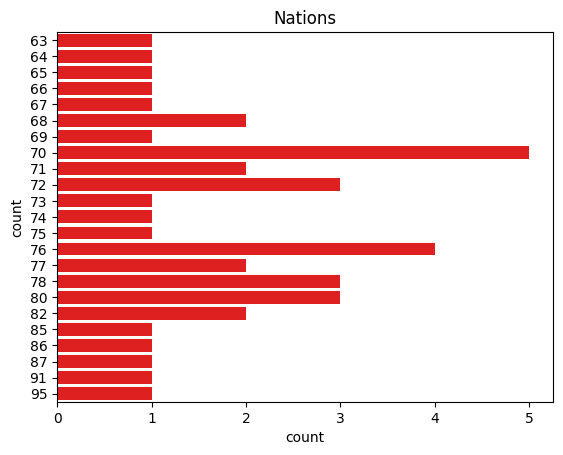

In [ ]:
sns.countplot(y=df1,data=df,color='r')
plt.title('Nations')

In [ ]:
df2=df['club'].value_counts()

Text(0.5, 1.0, 'clubs')

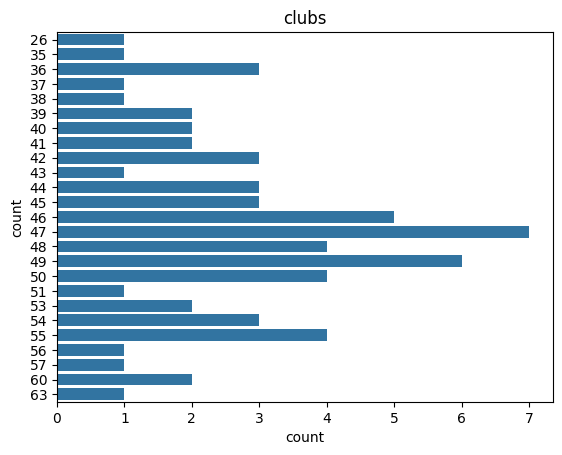

In [ ]:
sns.countplot(y=df2,data=df)
plt.title('clubs')

In [ ]:
df['market_value_million_eur'] = df['market_value_million_eur'].str.replace('M','').astype(float)

Text(0.5, 1.0, 'Transfer value')

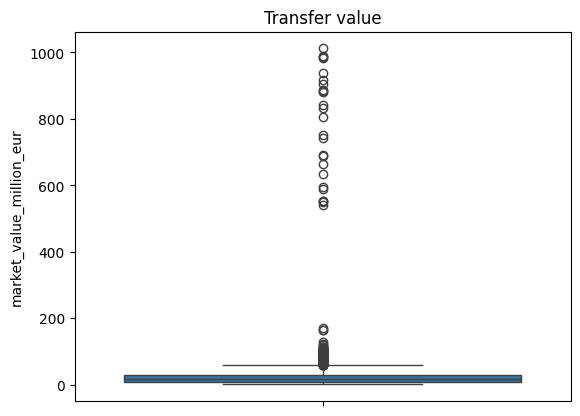

In [ ]:
sns.boxplot(y=df['market_value_million_eur'],data=df)
plt.title('Transfer value')

In [ ]:
Q1=df['market_value_million_eur'].quantile(0.25)
Q3=df['market_value_million_eur'].quantile(0.75)
IQR=Q3-Q1
lower_fence=Q1-1.5*IQR
upper_fence=Q3+1.5*IQR

In [ ]:
print(lower_fence,upper_fence)

-21.0 59.0


In [ ]:
df['market_value_million_eur']=df['market_value_million_eur'].clip(lower=lower_fence,upper=upper_fence)

Text(0.5, 1.0, 'Transfer value')

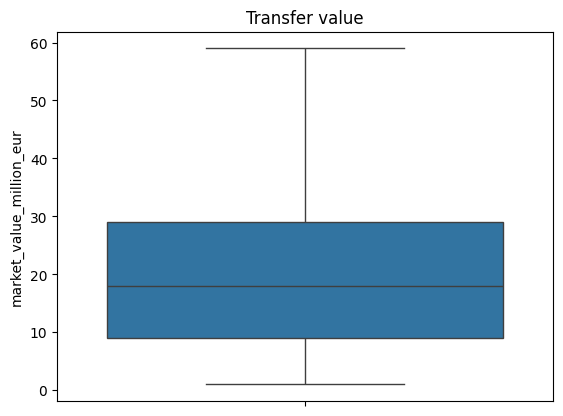

In [ ]:
sns.boxplot(y=df['market_value_million_eur'],data=df)
plt.title('Transfer value')

In [ ]:
df['age'].unique()

array([27., 25., 20., 21., 38., 29., 19., 23., 31., 22., 24., 33., 26.,
       30., 32., 34., 17., 28., 18., nan, 35., 36., 37.])

In [ ]:
df['contract_years_left'].unique()

array([ 2.,  1.,  0., nan,  5.,  3.,  4.])

In [ ]:
df['overall_rating'].unique()

array([91., 75., 88., 87., 86., 85., 84., 81., 83., nan, 68., 67., 62.,
       66., 74., 61., 82., 65., 64., 63., 71., 72., 80., 70., 79., 77.,
       69., 78., 60., 89., 76., 73.])

In [ ]:
df['age']=df['age'].fillna(df['age']).median()
df['contract_years_left']=df['contract_years_left'].fillna(df['contract_years_left']).median()
df['overall_rating']=df['overall_rating'].fillna(df['overall_rating']).median()

In [ ]:
df.isna().sum()

,0
player_name,0
age,0
nationality,0
club,0
overall_rating,0
potential_rating,0
market_value_million_eur,0
contract_years_left,0
injury_history,0
matches_played,0


In [ ]:
df_gd=pd.get_dummies(df[['nationality','club']],drop_first=True,dtype=int)
df_gd

,nationality_Argentina,nationality_Australia,nationality_Belgium,nationality_Brazil,nationality_Cameroon,nationality_Canada,nationality_Chile,nationality_Colombia,nationality_Croatia,nationality_Czech Republic,...,club_River Plate,club_Sevilla,club_Sporting CP,club_Stuttgart,club_Torino,club_Tottenham,club_Valencia,club_Villarreal,club_West Ham,club_Wolves
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df = df.drop(columns=['nationality', 'club', 'player_name'])

In [ ]:
df_con=df.copy()

In [ ]:
df

,age,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_history,matches_played,key_passes,dribbles,chances_created,pass_accuracy,transfer_risk_level
0,25.0,75.0,92,59.0,2.0,4,25,104,86,79,87.5,Low
1,25.0,75.0,92,43.0,2.0,6,16,110,60,39,85.8,High
2,25.0,75.0,94,59.0,2.0,5,32,92,45,91,77.3,High
3,25.0,75.0,93,59.0,2.0,4,20,110,23,26,94.7,High
4,25.0,75.0,87,4.0,2.0,4,24,85,58,33,76.9,High
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,25.0,75.0,83,2.0,2.0,1,40,98,61,24,86.3,High
2996,25.0,75.0,80,6.0,2.0,2,21,111,39,46,88.6,High
2997,25.0,75.0,97,59.0,2.0,2,13,91,92,82,84.5,High
2998,25.0,75.0,69,9.0,2.0,3,38,111,31,78,77.4,High


In [ ]:
# df_con=pd.concat([df,df_gd],axis=1)

In [ ]:
df_con

,age,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_history,matches_played,key_passes,dribbles,chances_created,pass_accuracy,transfer_risk_level
0,25.0,75.0,92,59.0,2.0,4,25,104,86,79,87.5,Low
1,25.0,75.0,92,43.0,2.0,6,16,110,60,39,85.8,High
2,25.0,75.0,94,59.0,2.0,5,32,92,45,91,77.3,High
3,25.0,75.0,93,59.0,2.0,4,20,110,23,26,94.7,High
4,25.0,75.0,87,4.0,2.0,4,24,85,58,33,76.9,High
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,25.0,75.0,83,2.0,2.0,1,40,98,61,24,86.3,High
2996,25.0,75.0,80,6.0,2.0,2,21,111,39,46,88.6,High
2997,25.0,75.0,97,59.0,2.0,2,13,91,92,82,84.5,High
2998,25.0,75.0,69,9.0,2.0,3,38,111,31,78,77.4,High


In [ ]:
from sklearn.preprocessing import LabelEncoder
le_target = LabelEncoder()
df['transfer_risk_level'] = le_target.fit_transform(df['transfer_risk_level'])

In [ ]:
x=df_con.drop(columns='transfer_risk_level')


In [ ]:
x

,age,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_history,matches_played,key_passes,dribbles,chances_created,pass_accuracy
0,25.0,75.0,92,59.0,2.0,4,25,104,86,79,87.5
1,25.0,75.0,92,43.0,2.0,6,16,110,60,39,85.8
2,25.0,75.0,94,59.0,2.0,5,32,92,45,91,77.3
3,25.0,75.0,93,59.0,2.0,4,20,110,23,26,94.7
4,25.0,75.0,87,4.0,2.0,4,24,85,58,33,76.9
...,...,...,...,...,...,...,...,...,...,...,...
2995,25.0,75.0,83,2.0,2.0,1,40,98,61,24,86.3
2996,25.0,75.0,80,6.0,2.0,2,21,111,39,46,88.6
2997,25.0,75.0,97,59.0,2.0,2,13,91,92,82,84.5
2998,25.0,75.0,69,9.0,2.0,3,38,111,31,78,77.4


In [ ]:
y=df_con['transfer_risk_level']

In [ ]:
y

,transfer_risk_level
0,Low
1,High
2,High
3,High
4,High
...,...
2995,High
2996,High
2997,High
2998,High


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape

(2400, 11)

In [ ]:
x_test.shape

(600, 11)

In [ ]:
y_train.shape

(2400,)

In [ ]:
y_test.shape

(600,)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler  = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)
x_train

array([[ 0.        ,  0.        , -0.65154494, ..., -0.494326  ,
         0.27560032, -0.89340015],
       [ 0.        ,  0.        ,  0.30148348, ..., -1.29275027,
        -0.54542779, -0.75903181],
       [ 0.        ,  0.        ,  0.83094372, ...,  1.25460333,
        -1.19540837,  1.61480883],
       ...,
       [ 0.        ,  0.        , -0.01619266, ..., -1.7109725 ,
        -1.19540837,  1.29008534],
       [ 0.        ,  0.        ,  0.40737553, ...,  0.60825988,
         1.57556149, -0.73663709],
       [ 0.        ,  0.        ,  0.61915962, ..., -0.15214418,
        -1.02436085,  0.3719017 ]])

In [ ]:
from imblearn.combine import SMOTETomek
smt = SMOTETomek(random_state=42)
x_train_res, y_train_res = smt.fit_resample(x_train, y_train)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train_res,y_train_res)
y_pred=model.predict(x_test)


In [ ]:
from sklearn.metrics import accuracy_score
score=accuracy_score(y_test,y_pred)

In [ ]:
score

0.79

              precision    recall  f1-score   support

        High       0.76      0.93      0.83       338
         Low       0.87      0.61      0.72       262

    accuracy                           0.79       600
   macro avg       0.81      0.77      0.78       600
weighted avg       0.80      0.79      0.78       600



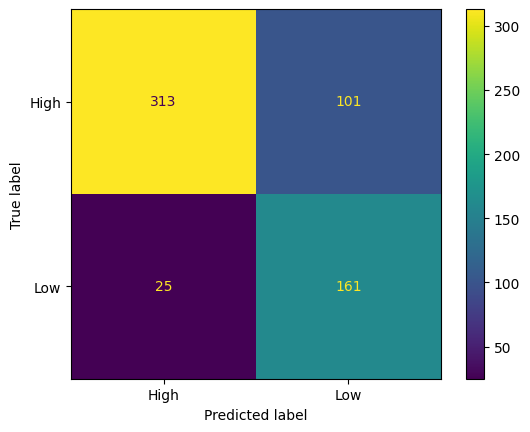

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print(classification_report(y_pred, y_test, target_names=['High','Low']))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['High','Low'])
plt.show()

In [ ]:
joblib.dump(model,'model_mid.pkl')
joblib.dump(scaler,'scaler_mid.pkl')
joblib.dump(le_target,'encoder_mid.pkl')

['encoder_mid.pkl']

In [ ]:
from google.colab import files
files.download('model_mid.pkl')
files.download('scaler_mid.pkl')
files.download('encoder_mid.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>